# 핵심 법인 282개 — 카드 급증·급감 조기 탐지 모델 (최종)

> **한 줄 결론:** 282개 핵심 법인의 카드 사용이 3개월 안에 **급증할지 급감할지**를 미리 맞힌다.
> 미개봉 시험 성적 **macro-F1 0.5465** — 특히 급감은 무작위 대비 **6.1배**로 잡아낸다.
> **급등 직후가 관리를 시작할 때, 급락 직후가 제안을 넣을 때다.**

**8부 구성:** ① 누구를 예측하나 → ② 무엇을 맞히나 → ③ 시험은 공정한가 → ④ 재료와 최대 발견 → ⑤ 어떤 모델이 이겼나 → ⑥ 성적표 → ⑦ 모델은 뭘 보고 판단하나 → ⑧ 요약

> 이 노트북은 **재학습 없이 저장된 모델·확률·표를 로드**해 공식 수치를 그대로 재현합니다 (실행 2~3분).
> 학습 과정 원본: `02_타겟정의` ~ `06_앙상블_평가` 노트북.

### 3분 용어 사전

| 용어 | 쉬운 말 |
|---|---|
| **급증 / 급감 / 유지** | 앞으로 3개월간 카드 사용이 크게 늘 것 / 줄 것 / 그대로일 것 (정확한 정의는 ②) |
| **macro-F1** | 세 클래스의 F1을 **같은 비중**으로 평균한 점수. 이 프로젝트의 주지표 |
| **AP** | 확률로 줄 세웠을 때 해당 클래스가 얼마나 앞에 몰리는지. **"무작위 대비 몇 배"로 읽는 게 핵심** |
| **데이터 누수** | 미래 정보가 학습에 몰래 섞이는 것. 시험 성적이 부풀려지는 원인 — 이 프로젝트는 4중으로 차단 |
| **백만원 단위** | 이 데이터의 금액 단위. `174.5` = 1.745억원 |


---
## ① 누구를 예측하나?

15,473개 법인을 다 예측하는 건 불가능하고 의미도 없습니다. **세 번 걸러서 282개**에 집중합니다.


In [1]:
# ============================================================
# 준비 + 깔때기: 15,473 → 3,372 → 2,819 → 282
# ============================================================
import sys, os, json, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from common import IM, LABEL_COLOR, SEED, set_korean_font, load_data, filtering_chain, ID, YM, CARD
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.width', 220)

df = load_data()
ch = filtering_chain(df)          # 팀 공용 모듈 — 모든 노트북이 같은 함수로 대상 선정
l1, l2, l3 = ch['l1_ids'], ch['l2_ids'], ch['l3_ids']

print(f'[깔때기] 전체 {df[ID].nunique():,}개')
print(f'  → 36개월 완전관측 {len(l1):,}개  (시계열 예측이 가능한 대상)')
print(f'  → 왜곡 제거 {len(l2):,}개  (카드액 39.9% 독식 1위 법인 + 무사용 552개 제외)')
print(f'  → 상위 10% 핵심군 {len(l3)}개  (학습기간 카드 사용액 상위 10%, 컷 {ch["train_total"].iloc[ch["k"]-1]:.1f}백만원)')

[깔때기] 전체 15,473개
  → 36개월 완전관측 3,372개  (시계열 예측이 가능한 대상)
  → 왜곡 제거 2,819개  (카드액 39.9% 독식 1위 법인 + 무사용 552개 제외)
  → 상위 10% 핵심군 282개  (학습기간 카드 사용액 상위 10%, 컷 174.5백만원)


상위 282개의 프로필: 최우수 등급 74.8% / 전담직원 관리 96.5%
→ "카드를 많이 쓰는 고객"과 "은행이 지켜야 할 고객"은 사실상 같은 집단


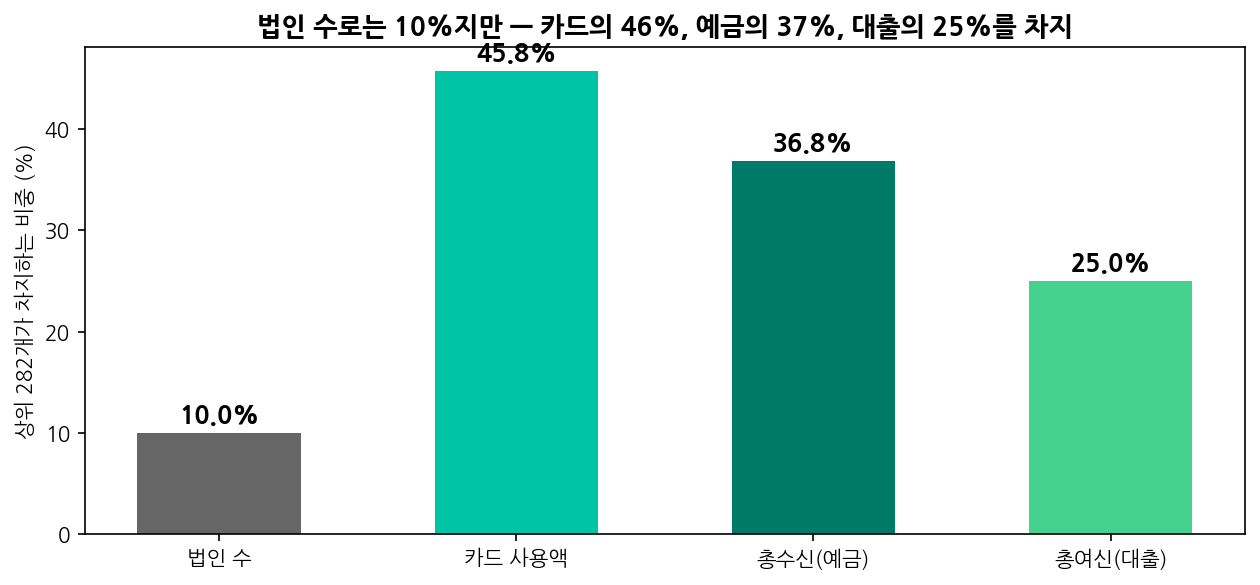

In [2]:
# ============================================================
# ①-근거 1: 왜 상위 10%인가 — "법인 10%가 은행 기여의 절반"
# ============================================================
d1 = df[df[ID].isin(l1) & (df[YM] >= 202302)].copy()
d1['총수신'] = d1[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
d1['총여신'] = d1['여신_운전자금대출잔액'] + d1['여신_시설자금대출잔액']
prof = d1[d1[ID].isin(l2)].groupby(ID)[[CARD, '총수신', '총여신']].mean()

is3 = prof.index.isin(l3)
share = {'법인 수': is3.mean(),
         '카드 사용액': ch['train_total'].loc[list(l3)].sum() / ch['train_total'].sum(),
         '총수신(예금)': prof.loc[is3, '총수신'].sum() / prof['총수신'].sum(),
         '총여신(대출)': prof.loc[is3, '총여신'].sum() / prof['총여신'].sum()}

snap = df[(df[YM] == 202512) & df[ID].isin(l3)]
print(f'상위 282개의 프로필: 최우수 등급 {(snap["법인_고객등급"] == "최우수").mean():.1%} / 전담직원 관리 {(snap["전담고객여부"] == "Y").mean():.1%}')
print('→ "카드를 많이 쓰는 고객"과 "은행이 지켜야 할 고객"은 사실상 같은 집단')

fig, ax = plt.subplots(figsize=(8.5, 4))
keys = list(share)
bars = ax.bar(keys, [share[k] * 100 for k in keys],
              color=[IM['그레이'], IM['민트'], IM['딥민트'], IM['그린']], width=0.55)
for b, k in zip(bars, keys):
    ax.text(b.get_x() + b.get_width() / 2, share[k] * 100 + 1, f'{share[k]:.1%}',
            ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('상위 282개가 차지하는 비중 (%)')
ax.set_title('법인 수로는 10%지만 — 카드의 46%, 예금의 37%, 대출의 25%를 차지', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()

In [3]:
# ============================================================
# ①-근거 2: 선정에도 누수 차단 — "전체 기간"이 아니라 "학습 기간"으로 뽑았다
# ============================================================
# 만약 36개월 전체 사용액으로 상위 10%를 뽑으면? → 시험 기간의 정보가 선정에 유입(누수)
tot36_l2 = ch['tot36'].loc[list(l2)].sort_values(ascending=False)
l3_wrong = set(tot36_l2.head(ch['k']).index)     # 잘못된 방식(전체 기간)
l3_right = set(l3)                               # 채택한 방식(학습 기간만)
swapped = len(l3_right - l3_wrong)

print(f'전체 기간 기준 vs 학습 기간 기준: 282개 중 {swapped}개({swapped / len(l3):.1%})가 교체됨')
print('→ 사소한 결정이 아니었다. 기준 하나로 대상의 13.5%가 달라진다')
print('→ 같은 원칙이 파이프라인 전체에 적용됨: 라벨 기준·인코딩·표준화 전부 학습 구간만으로 결정 (④에서 상술)')

전체 기간 기준 vs 학습 기간 기준: 282개 중 38개(13.5%)가 교체됨
→ 사소한 결정이 아니었다. 기준 하나로 대상의 13.5%가 달라진다
→ 같은 원칙이 파이프라인 전체에 적용됨: 라벨 기준·인코딩·표준화 전부 학습 구간만으로 결정 (④에서 상술)


### ① 정리

- **왜 282개인가**: 법인 수 10% = 카드 46% + 예금 37% + 대출 25%. 관리 자원이 한정될 때 여기부터 지키는 게 자원 배분상 합리적. (하위 90%는 법인당 사용액이 1/7이라 급변해도 개입 실익이 작음)
- **어떻게 뽑았나**: 학습 기간(2023.04~2024.03) 사용액만으로 — 전체 기간으로 뽑으면 38개가 바뀌는 실질적 누수였다.
- 제외된 552개(무사용)는 별도 트랙에서 분석 → `552_무사용법인_최종.ipynb`


---
## ② 무엇을 맞히나? — '급증'과 '급감'의 정의

매 기준월마다, 법인별로 두 창을 비교합니다:

- **현재 창** = 기준월 포함 직전 3개월의 카드 평균
- **미래 창** = 이후 3개월의 카드 평균

| 라벨 | 조건 (**둘 다** 충족) |
|---|---|
| **급증** | 변화율 +20% 이상 **AND** 변화액 +10백만원 이상 |
| **급감** | 변화율 −20% 이하 **AND** 변화액 −10백만원 이하 |
| **유지** | 그 외 전부 |

한 달 값이 아니라 **3개월 평균**을 쓰는 이유: 일시적 대규모 결제 같은 잡음을 걸러내고 "국면 전환"만 잡기 위해서입니다.


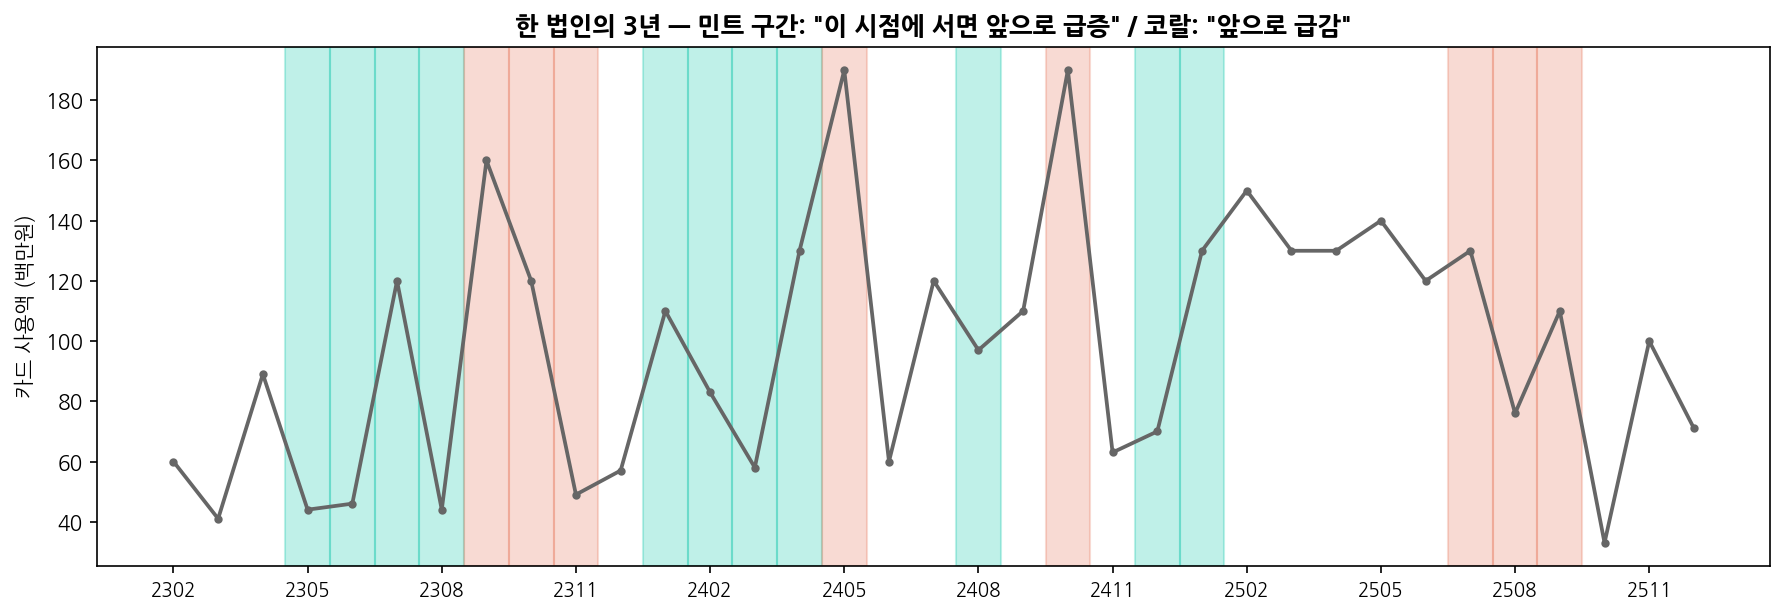

라벨 분포 (8,460건 = 282법인 × 30기준월): 급증 10.4% / 급감 10.4% / 유지 79.2%
→ 설계 목표(10/10/80)에 부합, 급증·급감이 정확히 대칭


In [4]:
# ============================================================
# ②-시각화: 라벨이 실제로 어떻게 생겼나 — 한 법인의 3년
# ============================================================
lab = pd.read_parquet('../data/processed/라벨_L3.parquet')
months = sorted(d1[YM].unique())

# 급증·급감을 모두 여러 번 겪은 법인 하나를 골라 눈으로 확인
cnt2 = lab.groupby('법인ID')['라벨'].value_counts().unstack().fillna(0)
pick = (cnt2['급증'].clip(upper=6) + cnt2['급감'].clip(upper=6)).idxmax()
ser = d1[d1[ID] == pick].set_index(YM)[CARD].reindex(months)
firm_lab = lab[lab['법인ID'] == pick].set_index('기준월')['라벨']

fig, ax = plt.subplots(figsize=(12, 4.2))
x = range(len(months))
ax.plot(x, ser.values, color=IM['그레이'], lw=1.8, marker='o', ms=3)
for i, m in enumerate(months):
    if m in firm_lab.index and firm_lab[m] in ('급증', '급감'):
        ax.axvspan(i - 0.5, i + 0.5, color=LABEL_COLOR[firm_lab[m]], alpha=0.25)
ax.set_xticks(x[::3]); ax.set_xticklabels([str(m)[2:] for m in months[::3]], fontsize=9)
ax.set_ylabel('카드 사용액 (백만원)')
ax.set_title(f'한 법인의 3년 — 민트 구간: "이 시점에 서면 앞으로 급증" / 코랄: "앞으로 급감"', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

dist = lab['라벨'].value_counts(normalize=True)
print(f'라벨 분포 (8,460건 = 282법인 × 30기준월): 급증 {dist["급증"]:.1%} / 급감 {dist["급감"]:.1%} / 유지 {dist["유지"]:.1%}')
print('→ 설계 목표(10/10/80)에 부합, 급증·급감이 정확히 대칭')

In [5]:
# ============================================================
# ②-근거: 왜 조건을 2개나 거나 — "가짜 급증"을 눈으로 확인
# ============================================================
fake = lab[(lab['변화율'] >= 0.20) & (lab['delta'] < 10) & (lab['delta'] > 0)]
print(f'비율 조건(+20%)만 쓰면 급증이 되지만, 금액 조건(+10백만원)이 걸러낸 사례: {len(fake):,}건')
print(f'  (비율 단독 시 급증의 {len(fake) / (len(fake) + (lab["라벨"] == "급증").sum()):.1%}가 이런 잡음)')
print()
print('실제 사례 3건 — "비율은 극단, 금액은 푼돈":')
ex = fake.nlargest(3, '변화율')[['past', 'future', 'delta', '변화율']]
for _, r in ex.iterrows():
    print(f'   월 {r["past"]:.2f} → {r["future"]:.2f}백만원 (변화율 +{r["변화율"]:.0%}, 변화액은 겨우 +{r["delta"]:.1f}백만원)')
print()
print('기준의 강건성: 비율 5단계 × 금액 5단계 = 25개 조합 전수 계산(02 노트북).')
print('  금액 조건을 빼면 분포가 26.5/23.2/50.2%로 무너지고, 금액 고정 시 비율을 10~30%로 바꿔도 급증 비율은 1.1%p만 변동')

비율 조건(+20%)만 쓰면 급증이 되지만, 금액 조건(+10백만원)이 걸러낸 사례: 1,357건
  (비율 단독 시 급증의 60.7%가 이런 잡음)

실제 사례 3건 — "비율은 극단, 금액은 푼돈":
   월 0.00 → 2.20백만원 (변화율 +65900%, 변화액은 겨우 +2.2백만원)
   월 0.04 → 9.01백만원 (변화율 +22433%, 변화액은 겨우 +9.0백만원)
   월 0.01 → 2.43백만원 (변화율 +18150%, 변화액은 겨우 +2.4백만원)

기준의 강건성: 비율 5단계 × 금액 5단계 = 25개 조합 전수 계산(02 노트북).
  금액 조건을 빼면 분포가 26.5/23.2/50.2%로 무너지고, 금액 고정 시 비율을 10~30%로 바꿔도 급증 비율은 1.1%p만 변동


### ② 정리

- **이중 조건의 이유**: 비율만 쓰면 "월 25만원 → 187만원(+647%)" 같은 소액 잡음 1,300여 건이 급증으로 잡힌다. 금액만 쓰면 대형 법인의 의미 있는 비율 변화를 놓친다. **둘 다 걸어야 "장사에 의미 있는 급변"만 남는다.**
- **기준(±20%, ±10백만)은 학습 구간 분포만으로 결정** — 라벨 기준 자체가 누수원이 되지 않도록.
- 라벨을 붙이고 보니 두 성질 발견: ① 급변은 **국면**이다(다음 달에도 급증일 확률 48.5%) ② **급감은 방치하면 안 돌아온다**(급감→급증 회복 6.8%) — 조기 개입의 수치적 근거.


---
## ③ 시험은 공정한가? — 시간 분할과 완충

무작위로 데이터를 섞어 나누면 안 됩니다. 실전은 항상 **"과거로 배워 미래를 맞히는"** 문제니까요.
그리고 시간순으로 나눠도 함정이 하나 남습니다 — **정답 창의 겹침**입니다.


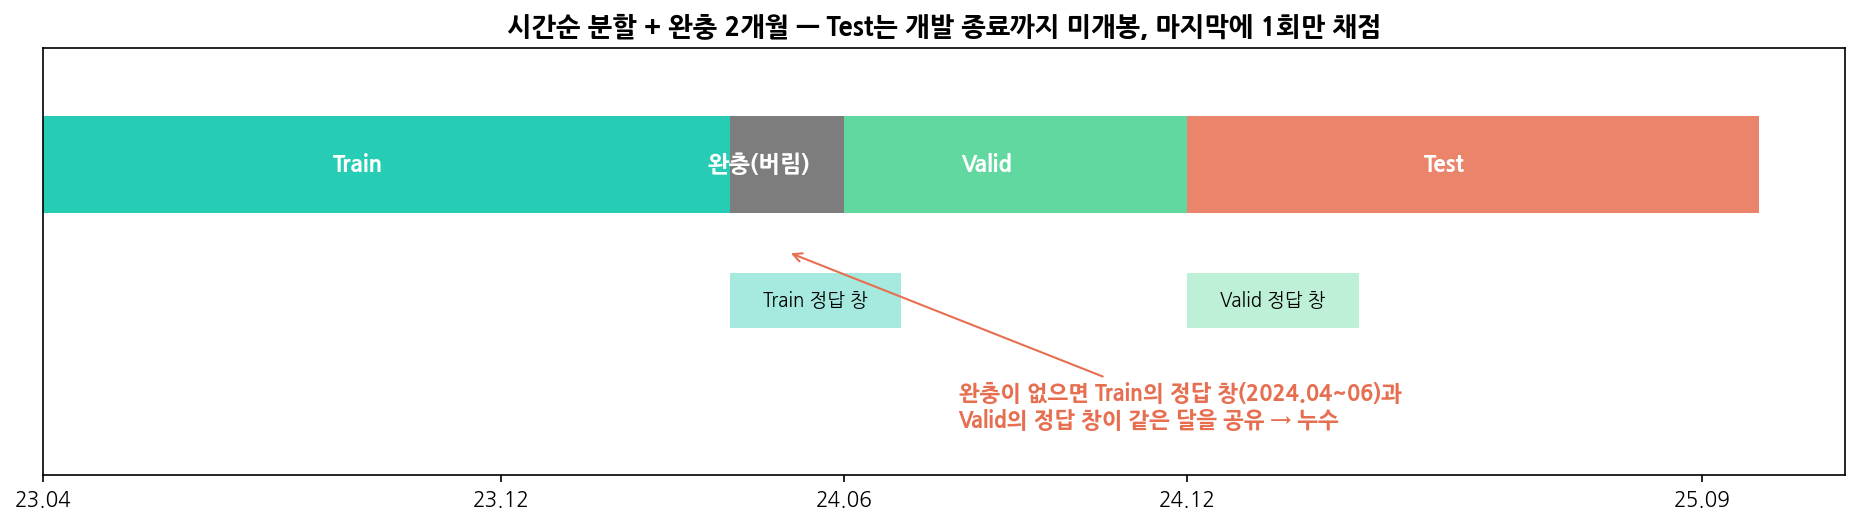

     구간   샘플  급증pct  급감pct  유지pct
  Train 3384   12.4   11.3   76.3
Embargo  564    7.4   14.2   78.4
  Valid 1692    7.7   10.6   81.7
   Test 2820   10.3    8.3   81.4

→ 급증 발생률이 12.4% → 7.7% → 10.3%로 시기마다 출렁인다(드리프트).
  무작위 분할이면 이 현실이 숨겨져 성적이 부풀었을 것 — 시간순 분할의 실증적 근거


In [6]:
# ============================================================
# ③-시각화: 시간 분할 타임라인 — 완충 2개월이 왜 필요한가
# ============================================================
mnum = {m: i for i, m in enumerate(sorted(lab['기준월'].unique()))}   # 202304~202509 → 0~29
splits = [('Train', 202304, 202403, IM['민트']),
          ('완충(버림)', 202404, 202405, IM['그레이']),
          ('Valid', 202406, 202411, IM['그린']),
          ('Test', 202412, 202509, IM['코랄'])]

fig, ax = plt.subplots(figsize=(12.5, 3.6))
for i, (name, s, e, color) in enumerate(splits):
    xs, xe = mnum[s], mnum[e]
    ax.barh(1, xe - xs + 1, left=xs, height=0.5, color=color, alpha=0.85)
    ax.text((xs + xe) / 2, 1, name, ha='center', va='center', fontsize=11, fontweight='bold', color='white')
# 정답 창: 각 구간의 마지막 기준월 + 3개월까지 라벨이 미래를 들여다봄
for name, s, e, color in [splits[0], splits[2]]:
    xe = mnum[e]
    ax.barh(0.3, 3, left=xe + 1 - 0.0, height=0.28, color=color, alpha=0.35)
    ax.text(xe + 2.5, 0.3, f'{name} 정답 창', ha='center', va='center', fontsize=9)
ax.annotate('완충이 없으면 Train의 정답 창(2024.04~06)과\nValid의 정답 창이 같은 달을 공유 → 누수',
            xy=(mnum[202404] + 1, 0.55), xytext=(mnum[202408], -0.35), fontsize=10.5,
            color=IM['코랄'], fontweight='bold', arrowprops=dict(arrowstyle='->', color=IM['코랄']))
ax.set_xticks([mnum[m] for m in [202304, 202312, 202406, 202412, 202509]])
ax.set_xticklabels(['23.04', '23.12', '24.06', '24.12', '25.09'])
ax.set_ylim(-0.6, 1.6); ax.set_yticks([])
ax.set_title('시간순 분할 + 완충 2개월 — Test는 개발 종료까지 미개봉, 마지막에 1회만 채점', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()

split_tbl = pd.read_csv('../outputs/tables/02_라벨분포_분할별.csv', encoding='utf-8-sig')
print(split_tbl.to_string(index=False))
print('\n→ 급증 발생률이 12.4% → 7.7% → 10.3%로 시기마다 출렁인다(드리프트).')
print('  무작위 분할이면 이 현실이 숨겨져 성적이 부풀었을 것 — 시간순 분할의 실증적 근거')

### ③ 정리

- **Train(12개월) → 완충 2개월 → Valid(6개월) → Test(10개월)**, 전부 시간순.
- **완충의 정확한 논리**: Train 마지막 기준월(2024.03)의 정답은 2024.04~06을 들여다본다. Valid가 2024.04부터 시작하면 **같은 달의 결과가 학습 정답과 검증 정답에 동시에 들어간다.** 2개월을 버려서 정답 창의 겹침을 0으로 만들었다.
- **Test는 모든 개발이 끝날 때까지 미개봉**, 마지막에 딱 1회 채점 — ⑥의 성적이 믿을 수 있는 이유.


---
## ④ 모델의 재료 — 그리고 이 프로젝트 최대의 발견

**재료 104개**: 원본 컬럼(구간 문자 29개는 중앙값으로 숫자화) + 카드 이력 요약 파생 35개(최근 3개월 평균, 변동성, 추세, 모멘텀, 전년 동월 대비, 계절 등) − 중복·저가치 17개 제거.

**누수 4중 방어** (이 프로젝트의 관통 원칙):

| # | 방어선 | 내용 |
|---|---|---|
| 1 | 대상 선정 | 상위 10%를 학습 기간 사용액만으로 (①) |
| 2 | 라벨 기준 | ±20%/±10백만을 학습 구간 분포만으로 (②) |
| 3 | 피처 | 전 파생변수 기준월 이전 정보만 + 표본 5건 손계산 대조(최대 오차 5.6×10⁻¹⁶) |
| 4 | 변환 통계 | 인코딩·결측 대체·표준화 전부 Train에만 적합(fit), Valid/Test는 적용(transform)만 |

그리고 재료를 만들다 **최대 발견**이 나왔습니다.


             급증 중앙값(Train)  급감 중앙값(Train)  유지 중앙값(Train)
카드_3개월평균             21.12          44.00          19.50
카드_전분기차              -2.33          14.74           0.60
카드_전년동월비             -0.08           0.20          -0.05
카드_최근6개월z            -0.28           0.14          -0.09
카드_6개월추세기울기          -0.40           3.20           0.17
카드_모멘텀                0.90           1.12           0.96


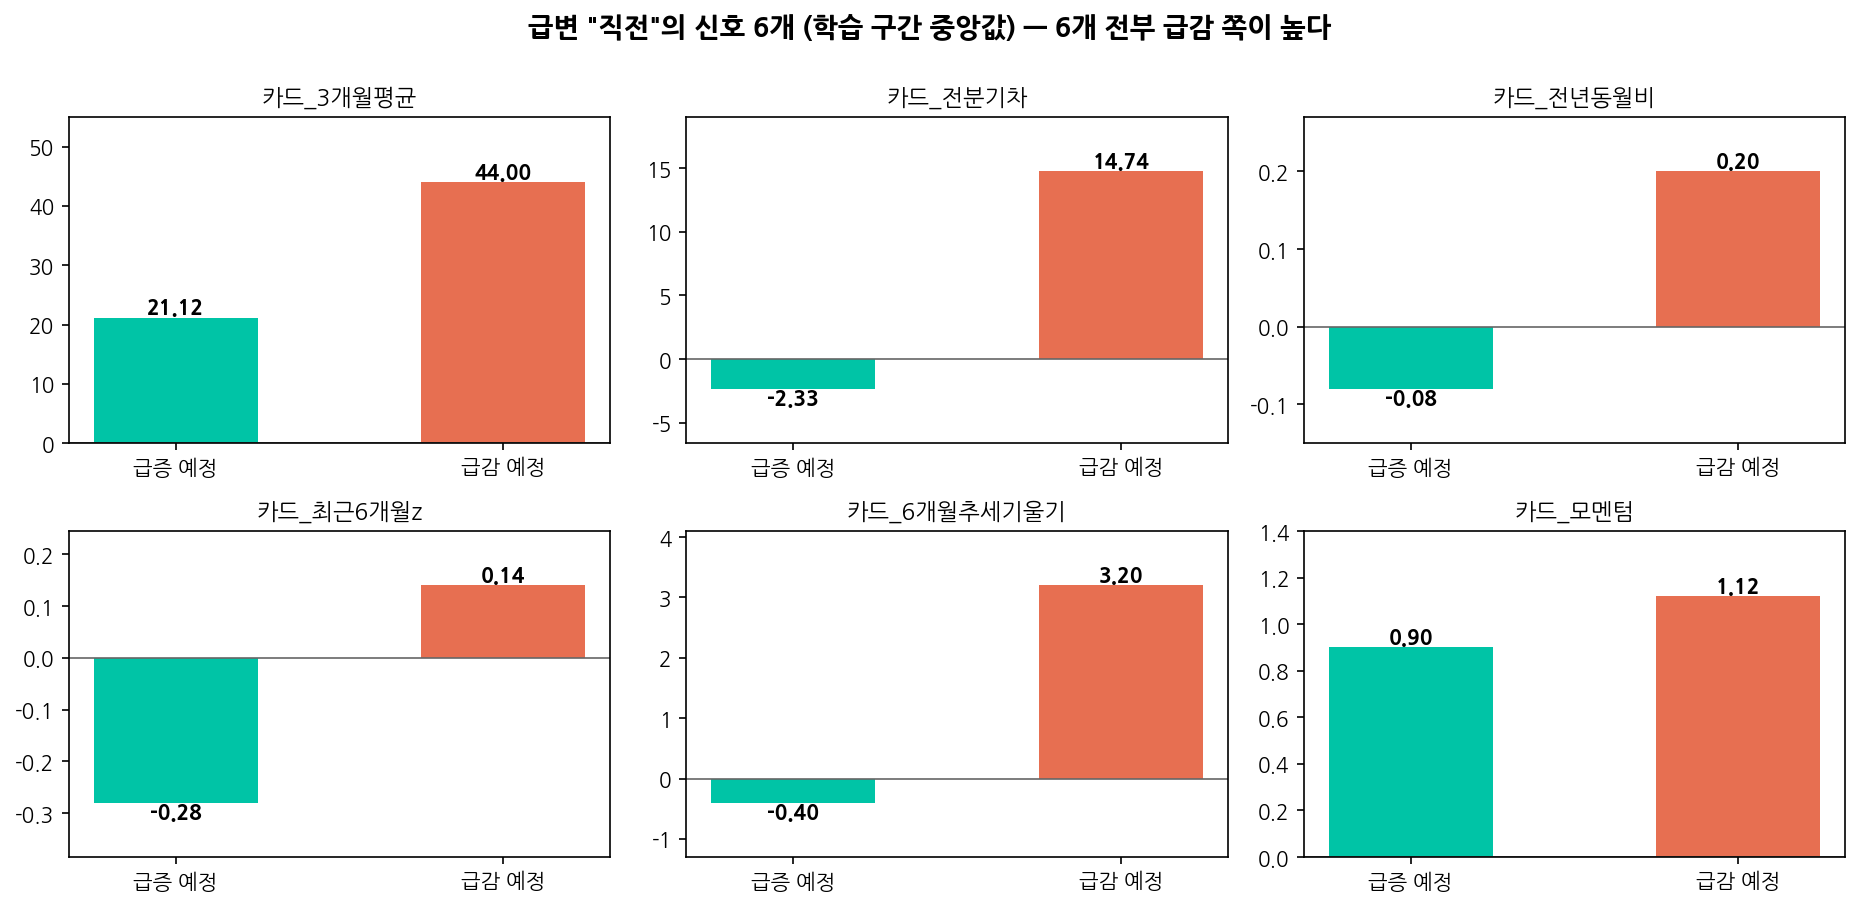

읽는 법: 곧 급감할 법인(코랄)은 지금 많이 쓰고·급하게 늘어난 상태, 곧 급증할 법인(민트)은 적게 쓰고·꺾여 있는 상태.
→ 당초 기대한 "오르던 법인이 계속 오른다(관성)"는 6개 지표 전부에서 기각. 주가의 "많이 오르면 조정 온다"와 같은 구조


In [7]:
# ============================================================
# ④-발견: 평균회귀 — "많이 쓰던 곳이 꺾이고, 꺾인 곳이 반등한다"
# ============================================================
mr = pd.read_csv('../outputs/tables/03_평균회귀_검증.csv', encoding='utf-8-sig', index_col=0)
print(mr.to_string())

fig, axes = plt.subplots(2, 3, figsize=(12.5, 6))
for ax, (feat, row) in zip(axes.flat, mr.iterrows()):
    up, dn = row['급증 중앙값(Train)'], row['급감 중앙값(Train)']
    bars = ax.bar(['급증 예정', '급감 예정'], [up, dn], color=[IM['민트'], IM['코랄']], width=0.5)
    for b, v in zip(bars, [up, dn]):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:,.2f}', ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=10, fontweight='bold')
    ax.axhline(0, color=IM['그레이'], lw=0.8)
    ax.set_title(feat, fontsize=11)
    ax.margins(y=0.25)
fig.suptitle('급변 "직전"의 신호 6개 (학습 구간 중앙값) — 6개 전부 급감 쪽이 높다',
             fontsize=13, fontweight='bold', y=1.0)
plt.tight_layout(); plt.show()

print('읽는 법: 곧 급감할 법인(코랄)은 지금 많이 쓰고·급하게 늘어난 상태, 곧 급증할 법인(민트)은 적게 쓰고·꺾여 있는 상태.')
print('→ 당초 기대한 "오르던 법인이 계속 오른다(관성)"는 6개 지표 전부에서 기각. 주가의 "많이 오르면 조정 온다"와 같은 구조')

### ④ 정리

**카드 사용은 평균회귀한다.** 이 발견 하나가 이후 결과 전부를 설명합니다:
- 왜 **급감이 잘 잡히는가** → "고점에서 꺾인다"는 신호가 뚜렷해서 (⑥)
- 왜 **급증이 어려운가** → "바닥에서 반등한다"는 신호는 잡음이 많아서 (⑥)
- 모델이 실제로 이 법칙을 배웠는가 → SHAP으로 재확인 (⑦)


---
## ⑤ 어떤 모델이 이겼나?

### 먼저, 채점 기준부터 — 왜 정확도(accuracy)가 아닌가

이 데이터는 79%가 '유지'입니다. 그래서 **아무것도 배우지 않은 모델도 정확도가 높게 나옵니다.** 말로 하면 안 믿기니 실측합니다.


In [8]:
# ============================================================
# ⑤-실측: 정확도의 함정 — 전부 '유지'로 찍는 바보 모델
# ============================================================
from sklearn.metrics import f1_score, accuracy_score
ms = pd.read_parquet('../data/processed/모델셋_최종_L3.parquet')
valid = ms[ms['구간'] == 'Valid']
dummy_pred = np.array(['유지'] * len(valid))
print(f'전부 "유지"로 찍는 모델의 검증 성적:')
print(f'   정확도  : {accuracy_score(valid["라벨"], dummy_pred):.4f}  ← 아무것도 안 배웠는데 82점!')
print(f'   macro-F1: {f1_score(valid["라벨"], dummy_pred, average="macro"):.4f}  ← 진실은 여기에')
print()
print('→ 정확도는 이 문제에서 성능을 속이는 지표. 주지표는 macro-F1(세 클래스 동등 가중) + PR-AUC(확률 순위 품질)')

전부 "유지"로 찍는 모델의 검증 성적:
   정확도  : 0.8168  ← 아무것도 안 배웠는데 82점!
   macro-F1: 0.2997  ← 진실은 여기에

→ 정확도는 이 문제에서 성능을 속이는 지표. 주지표는 macro-F1(세 클래스 동등 가중) + PR-AUC(확률 순위 품질)


### 지표에 대한 예상 질문 3연타 — 미리 답해둡니다

**Q1. 급증·급감·유지 각각의 F1은 안 봤나?**
봤습니다(전 지표 CSV에 저장). 다만 역할이 다릅니다 — **선발에는 하나로 합친 지표**(44개 조합을 줄 세우려면 스칼라가 필요), **진단에는 쪼갠 지표**(MLP의 급증 재현율 45.4%가 앙상블 채택의 근거). macro-F1은 클래스별 F1 세 개의 동등 가중 평균이므로 "안 본" 게 아니라 "합쳐서 선발에 쓴" 것입니다.

**Q2. PR-AUC는 왜 클래스별 AP로 쪼개서 인용하나?**
평균이 비대칭을 숨기기 때문입니다. PR-AUC 0.567 하나만 보면 밋밋하지만, 쪼개면 **급감 AP 0.509(기저율의 6.1배) vs 급증 AP 0.261(2.5배)** — 평균회귀 구조와 연결되는 핵심 발견이 보입니다. AP는 기저율이 밑바닥이라 "몇 배" 해석이 가능한데, 평균 낸 값에는 그 기준선이 없습니다.

**Q3. 왜 ROC-AUC가 아니라 PR-AUC인가?**
ROC-AUC는 분모에 거대한 다수 클래스(유지)가 들어가 희소 클래스 문제에서 낙관적으로 부풀어요. PR-AUC는 거짓 경보의 비용이 정밀도에 그대로 반영됩니다 — 불균형 분류의 표준.

### 이제 4단계 경쟁


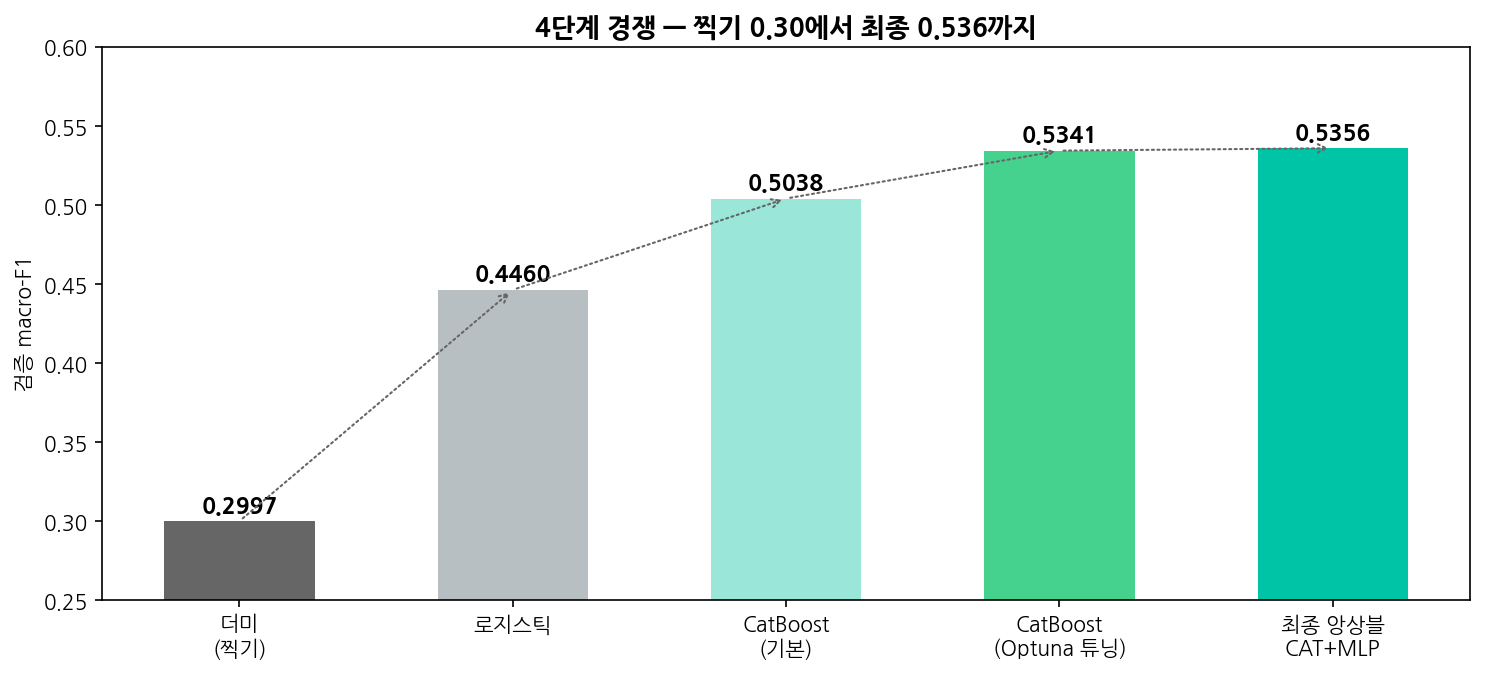

MLP(신경망)는 종합 0.5136로 2위였지만 —
   급증 재현율 45.4% (트리 최고 34.6%의 1.3배), CatBoost와 예측 21% 불일치
   → "다른 것을 보는 모델"이라 앙상블 후보로 유지

앙상블: 모델 부분집합 11개 × 결합 4종 = 44가지 전수 비교 →
   CatBoost 단독(0.5341)을 넘은 조합은 단 1개: CAT 98.8% + MLP 1.2% 가중평균 (0.5356)
   스태킹은 전멸(검증 1,692건으로 메타모델 학습은 과적합 대비 이득 없음)
   → 최종 모델: CatBoost(Optuna) 0.988 + MLP 0.012 소프트 보팅. 레시피 동결 후 Test로


In [9]:
# ============================================================
# ⑤-경쟁: 더미 → 베이스라인 → 자동튜닝 → 앙상블 (전부 검증 기준)
# ============================================================
base = pd.read_csv('../outputs/tables/04_valid_전지표.csv', encoding='utf-8-sig', index_col=0)
opt = pd.read_csv('../outputs/tables/05_optuna_valid_비교.csv', encoding='utf-8-sig', index_col=0)
mlp = pd.read_csv('../outputs/tables/05_MLP_valid_비교.csv', encoding='utf-8-sig', index_col=0)
recipe = json.load(open('../models/06_앙상블_레시피.json', encoding='utf-8'))

stages = [('더미\n(찍기)', base.loc['더미(다수결)', 'F1(macro)'], IM['그레이']),
          ('로지스틱', base.loc['로지스틱(균형)', 'F1(macro)'], IM['중립']),
          ('CatBoost\n(기본)', base.loc['CatBoost(균형)', 'F1(macro)'], IM['연민트']),
          ('CatBoost\n(Optuna 튜닝)', opt.loc['CatBoost(Optuna)', 'F1(macro)'], IM['그린']),
          ('최종 앙상블\nCAT+MLP', recipe['valid_f1_argmax'], IM['민트'])]

fig, ax = plt.subplots(figsize=(10, 4.6))
xs = range(len(stages))
bars = ax.bar(xs, [s[1] for s in stages], color=[s[2] for s in stages], width=0.55)
for i, (name, v, c) in enumerate(stages):
    ax.text(i, v + 0.006, f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
    if i > 0:
        ax.annotate('', xy=(i, v), xytext=(i - 1, stages[i - 1][1]),
                    arrowprops=dict(arrowstyle='->', color=IM['그레이'], lw=1, ls=':'))
ax.set_xticks(xs); ax.set_xticklabels([s[0] for s in stages], fontsize=10)
ax.set_ylabel('검증 macro-F1'); ax.set_ylim(0.25, 0.60)
ax.set_title('4단계 경쟁 — 찍기 0.30에서 최종 0.536까지', fontsize=12.5, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'MLP(신경망)는 종합 {mlp.loc["MLP(집계피처)", "F1(macro)"]:.4f}로 2위였지만 —')
print(f'   급증 재현율 {mlp.loc["MLP(집계피처)", "recall_급증"]:.1%} (트리 최고 {opt["recall_급증"].max():.1%}의 1.3배), CatBoost와 예측 21% 불일치')
print(f'   → "다른 것을 보는 모델"이라 앙상블 후보로 유지')
print()
print(f'앙상블: 모델 부분집합 11개 × 결합 4종 = 44가지 전수 비교 →')
print(f'   CatBoost 단독(0.5341)을 넘은 조합은 단 1개: CAT {recipe["weights"][0]:.1%} + MLP {recipe["weights"][1]:.1%} 가중평균 ({recipe["valid_f1_argmax"]:.4f})')
print(f'   스태킹은 전멸(검증 1,692건으로 메타모델 학습은 과적합 대비 이득 없음)')
print(f'   → 최종 모델: CatBoost(Optuna) 0.988 + MLP 0.012 소프트 보팅. 레시피 동결 후 Test로')

### ⑤ 정리

| 단계 | 검증 macro-F1 | 배운 것 |
|---|---:|---|
| 더미(전부 유지) | 0.2997 | 출발선 |
| 베이스라인 CatBoost | 0.5038 | 트리 부스팅 우위, 급감은 잡히고 급증은 어렵다 |
| Optuna 튜닝 | 0.5341 | "깊게 만들되 강하게 규제" |
| MLP | 0.5136 | 순위는 2위지만 급증을 다르게 잡는다 |
| **최종 앙상블** | **0.5356** | 44조합 중 유일하게 단독을 넘은 CAT 98.8% + MLP 1.2% |


---
## ⑥ 성적표 — 한 번도 안 본 시험 데이터 2,820건

저장된 Test 확률을 로드해 공식 성적을 그대로 재현합니다. (재현 검증: 공식 수치와 일치해야만 통과하는 assert 포함)


★ Test macro-F1 0.5465 — 공식 보고값과 일치 (검증 0.5356보다 +0.011 → 일반화 성립)

   급감 AP 0.509 = 기저율 8.3%의 ×6.1
   급증 AP 0.261 = 기저율 10.3%의 ×2.5

                      운영점  F1(macro)  AP_급증  AP_급감  recall_급감  precision_급감
                기본 argmax     0.5465 0.2613 0.5085     0.4723        0.4826
확정 임계(w_급감=2.4, w_급증=0.9)     0.5356 0.2613 0.5085     0.6128        0.3731

정직한 발견: 검증에서 +0.016 이득이던 운영 임계가 Test에선 −0.011 역효과 — 임계가 검증에 과적합.
             다만 그 운영점은 급감 재현율 61.3%로, "F1 최적점"이 아닌 "조기경보 운영점"으로 용도 재규정.


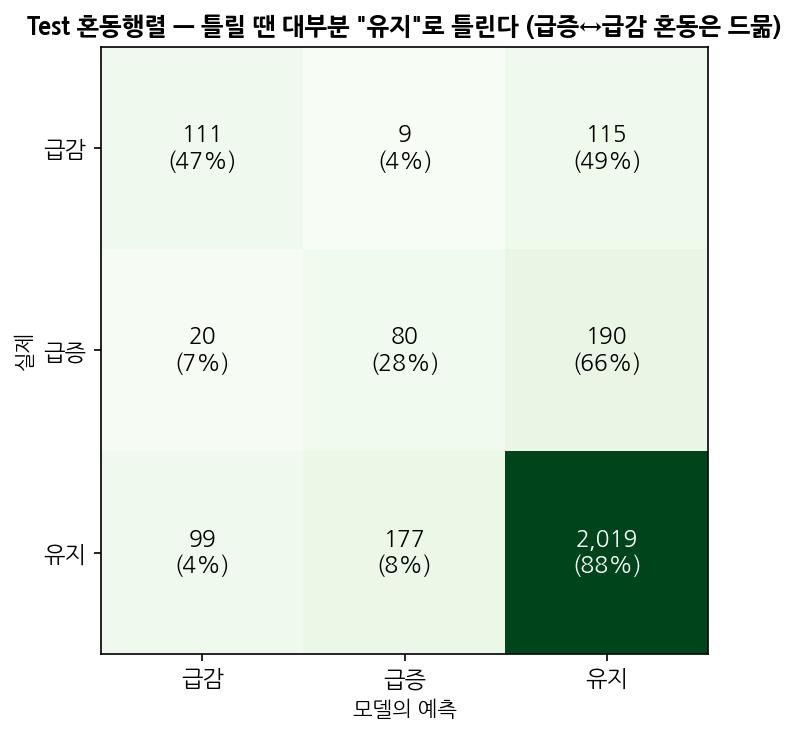

In [10]:
# ============================================================
# ⑥-재현: 미개봉 Test 1회 채점
# ============================================================
from sklearn.metrics import confusion_matrix, average_precision_score
CLS = ['급감', '급증', '유지']                     # 확률 배열의 클래스 순서 (02~06 공통)
P = np.load('../models/06_test_probas.npy')       # (4모델, 2820, 3) — [LGBM, XGB, CAT, MLP]
test = ms[ms['구간'] == 'Test']
y = test['라벨'].values

w = recipe['weights']
ens = w[0] * P[2] + w[1] * P[3]                   # CAT(idx2) + MLP(idx3)
pred = np.array(CLS)[ens.argmax(1)]

f1 = f1_score(y, pred, average='macro')
assert abs(f1 - 0.5465) < 1e-3, '공식 수치 재현 실패!'
print(f'★ Test macro-F1 {f1:.4f} — 공식 보고값과 일치 (검증 0.5356보다 +0.011 → 일반화 성립)')
print()
for i, c in enumerate(['급감', '급증']):
    ap = average_precision_score((y == c).astype(int), ens[:, CLS.index(c)])
    base_rate = (y == c).mean()
    print(f'   {c} AP {ap:.3f} = 기저율 {base_rate:.1%}의 ×{ap / base_rate:.1f}')
print()
official = pd.read_csv('../outputs/tables/06_TEST_공식성능.csv', encoding='utf-8-sig')
print(official[['운영점', 'F1(macro)', 'AP_급증', 'AP_급감', 'recall_급감', 'precision_급감']].to_string(index=False))
print()
print('정직한 발견: 검증에서 +0.016 이득이던 운영 임계가 Test에선 −0.011 역효과 — 임계가 검증에 과적합.')
print('             다만 그 운영점은 급감 재현율 61.3%로, "F1 최적점"이 아닌 "조기경보 운영점"으로 용도 재규정.')

cm = confusion_matrix(y, pred, labels=CLS)
fig, ax = plt.subplots(figsize=(6.2, 5))
im_ = ax.imshow(cm, cmap='Greens')
for i in range(3):
    for j in range(3):
        ax.text(j, i, f'{cm[i, j]:,}\n({cm[i, j] / cm[i].sum():.0%})', ha='center', va='center',
                fontsize=11, color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
ax.set_xticks(range(3)); ax.set_xticklabels(CLS, fontsize=11)
ax.set_yticks(range(3)); ax.set_yticklabels(CLS, fontsize=11)
ax.set_xlabel('모델의 예측'); ax.set_ylabel('실제')
ax.set_title('Test 혼동행렬 — 틀릴 땐 대부분 "유지"로 틀린다 (급증↔급감 혼동은 드묾)', fontsize=11.5, fontweight='bold')
plt.tight_layout(); plt.show()

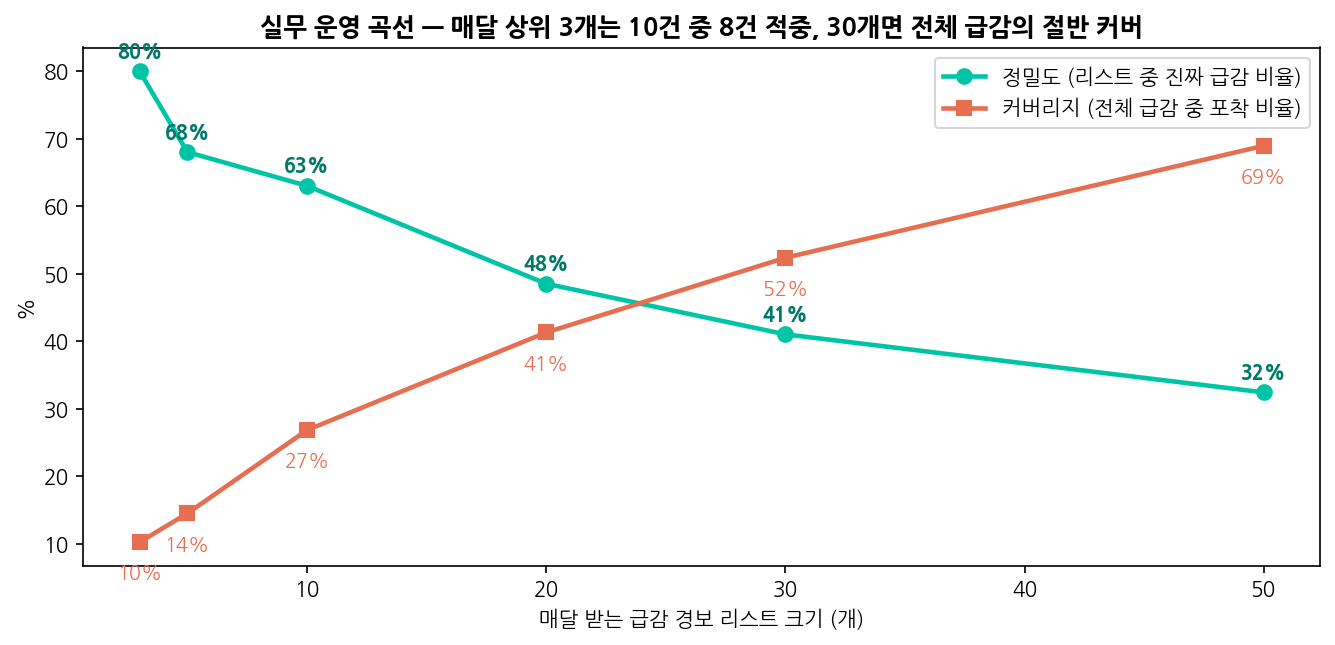

예: 매달 급감 확률 상위 3개 리스트 → 정밀도 80%
    매달 상위 30개 리스트 → 정밀도 41%, 시험 10개월 전체 급감의 52% 커버


In [11]:
# ============================================================
# ⑥-실무 번역: "매달 몇 개 리스트를 주면, 몇 개가 진짜인가"
# ============================================================
tt = test[['기준월', '라벨']].copy()
tt['p급감'] = ens[:, 0]

sizes = [3, 5, 10, 20, 30, 50]
prec, cover = [], []
n_down_total = (tt['라벨'] == '급감').sum()
for k in sizes:
    hits = tot = 0
    for _, g in tt.groupby('기준월'):
        top = g.nlargest(k, 'p급감')
        hits += (top['라벨'] == '급감').sum(); tot += len(top)
    prec.append(hits / tot); cover.append(hits / n_down_total)

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(sizes, [p * 100 for p in prec], marker='o', ms=7, lw=2.2, color=IM['민트'], label='정밀도 (리스트 중 진짜 급감 비율)')
ax.plot(sizes, [c * 100 for c in cover], marker='s', ms=7, lw=2.2, color=IM['코랄'], label='커버리지 (전체 급감 중 포착 비율)')
for k, p, c in zip(sizes, prec, cover):
    ax.text(k, p * 100 + 2, f'{p:.0%}', ha='center', fontsize=9.5, color=IM['딥민트'], fontweight='bold')
    ax.text(k, c * 100 - 5.5, f'{c:.0%}', ha='center', fontsize=9.5, color=IM['코랄'])
ax.set_xlabel('매달 받는 급감 경보 리스트 크기 (개)'); ax.set_ylabel('%')
ax.set_title('실무 운영 곡선 — 매달 상위 3개는 10건 중 8건 적중, 30개면 전체 급감의 절반 커버', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

print(f'예: 매달 급감 확률 상위 3개 리스트 → 정밀도 {prec[0]:.0%}')
print(f'    매달 상위 30개 리스트 → 정밀도 {prec[4]:.0%}, 시험 10개월 전체 급감의 {cover[4]:.0%} 커버')

### ⑥ 정리

- **공식 성적: macro-F1 0.5465 / 급감 AP ×6.1 / 급증 AP ×2.5** — 검증보다 높아 일반화 성립.
- **급감이 잘 잡히는 이유 = ④의 평균회귀.** 고점에서 꺾이는 신호는 뚜렷하고, 바닥 반등 신호는 잡음이 많다.
- 실무 번역: **매달 상위 3개 리스트 = 80% 적중, 상위 30개 = 급감의 절반 커버.** RM 조직이 바로 쓸 수 있는 형태.
- 검증에 과적합된 운영 임계를 숨기지 않고 보고 — 대신 "급감 61.3% 사전 포착" 조기경보 운영점으로 용도를 재규정.


---
## ⑦ 모델은 무엇을 보고 판단하나? (SHAP)

성능이 좋아도 **왜 그렇게 판단하는지** 설명 못 하면 현장에서 못 씁니다. 판단 근거를 변수별로 분해(SHAP)했습니다.


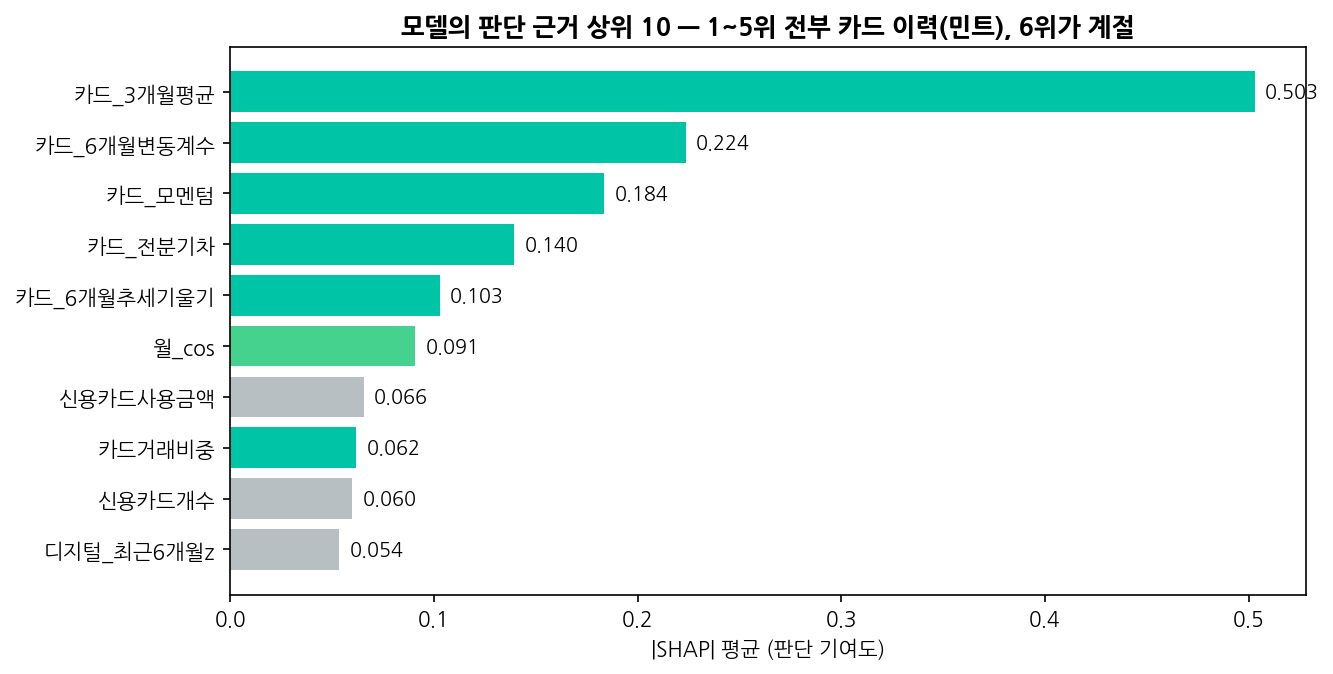

             ρ(값, SHAP_급감)  ρ(값, SHAP_급증) 평균회귀 부합
피처                                               
카드_3개월평균             0.960         -0.932       예
카드_전분기차              0.948         -0.967       예
카드_전년동월비             0.138          0.641     아니오
카드_최근6개월z            0.647         -0.469       예
카드_6개월추세기울기          0.796         -0.908       예
카드_모멘텀               0.976         -0.976       예

→ 6개 지표 중 5개에서 평균회귀가 모델 안에서 재확인 (값이 클수록 급감 쪽으로 판단, ρ 최대 0.96)
→ 유일한 예외: 카드_전년동월비는 급증과 같은 방향(+0.64) —
   모델이 배운 법칙은 이중 구조다: "단기 과열은 되돌아오지만, 1년 단위 성장 추세는 이어진다"


In [12]:
# ============================================================
# ⑦-해석: 중요도 상위 10 + 평균회귀 재확인
# ============================================================
shap_imp = pd.read_csv('../outputs/tables/06_SHAP_중요도.csv', encoding='utf-8-sig', index_col=0)
top10 = shap_imp['전체'].head(10)

fig, ax = plt.subplots(figsize=(9, 4.6))
colors = [IM['민트'] if s.startswith('카드') else (IM['그린'] if '월' in s and len(s) <= 5 else IM['중립']) for s in top10.index]
ax.barh(range(len(top10)), top10.values, color=colors)
for i, v in enumerate(top10.values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9.5)
ax.set_yticks(range(len(top10))); ax.set_yticklabels(top10.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('|SHAP| 평균 (판단 기여도)')
ax.set_title('모델의 판단 근거 상위 10 — 1~5위 전부 카드 이력(민트), 6위가 계절', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

mrv = pd.read_csv('../outputs/tables/06_SHAP_평균회귀검증.csv', encoding='utf-8-sig', index_col=0)
print(mrv.to_string())
print()
print('→ 6개 지표 중 5개에서 평균회귀가 모델 안에서 재확인 (값이 클수록 급감 쪽으로 판단, ρ 최대 0.96)')
print('→ 유일한 예외: 카드_전년동월비는 급증과 같은 방향(+0.64) —')
print('   모델이 배운 법칙은 이중 구조다: "단기 과열은 되돌아오지만, 1년 단위 성장 추세는 이어진다"')

### ⑦ 정리

- **카드 자체의 이력이 판단의 대부분** (1~5위: 3개월 평균, 변동계수, 모멘텀, 전분기 차, 추세). 계절이 6위 — EDA의 4월 피크 발견이 실제로 쓰임. 예금·대출 정보는 보조.
- **평균회귀 5/6 재확인 + 전년 동월비 예외** → "단기 되돌림 + 연간 추세 지속"의 이중 구조.
- 한 줄 요약: **급등 직후가 축하할 때가 아니라 관리를 시작할 때고, 급락 직후가 영업 제안의 적기다.**

---

# ⑧ 최종 요약 — 한 장

**스토리 6줄:**
1. **법인 10%(282개)가 카드 46%·예금 37%·대출 25%를 차지** — 여기에 집중한다. 선정부터 누수 차단(38개 교체 확인).
2. 타겟은 **3개월 평균 vs 3개월 평균, 비율 AND 금액 이중 조건** — 가짜 급증 1,300건을 걸러낸 설계. 분포 10/10/80.
3. **시간순 분할 + 완충 2개월 + Test 미개봉 1회 채점** — 성적을 믿을 수 있는 이유.
4. 최대 발견: **카드 사용은 평균회귀한다.** 관성 가설은 6개 지표 전부에서 기각.
5. 4단계 경쟁 끝에 **CatBoost 0.988 + MLP 0.012** — Test macro-F1 **0.5465**(검증보다 높아 일반화), 급감 **×6.1**·급증 ×2.5.
6. SHAP: 판단 근거 1~5위 전부 카드 이력, "단기 되돌림 + 연간 추세 지속"의 이중 구조까지 해석 완료.

**은행이 할 일:**
- **급감 경보** → 이탈 방지: 매달 상위 30개 리스트(정밀도 41%, 커버 52%) 또는 조기경보 운영점(포착 61.3%)
- **급증 경보** → 선제 여신 영업: 급증 후 6개월간 대출 +266백만·예금 −482백만(이벤트 스터디) — 대출 수요의 선행 신호

**정직한 한계:**
- 금액이 반올림·구간화된 가상 데이터 — 절대 수치는 실전과 다를 수 있음
- 급증 예측은 여전히 어려움(×2.5) — 데이터의 구조적 특성(평균회귀)
- 운영 임계는 검증 과적합이 확인되어 F1 최적점이 아닌 조기경보 용도로만
